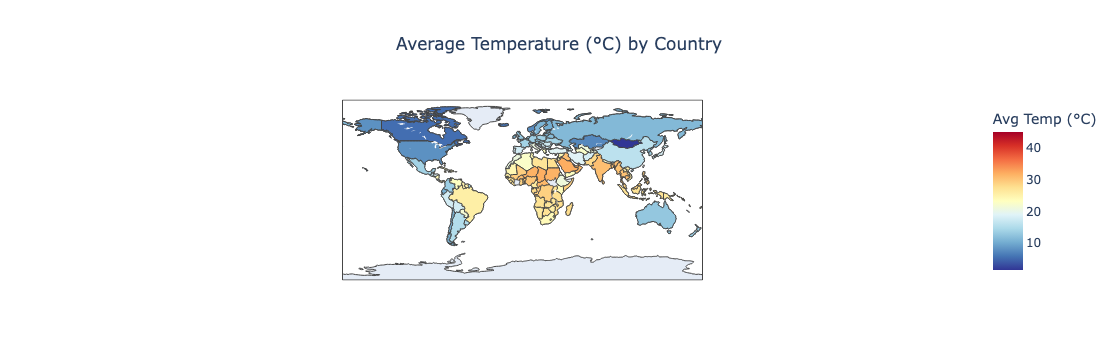

In [10]:
import plotly.express as px
import pandas as pd

# Exploratory Data Analysis (EDA) - World Map - Average Temperature in Celcius
df = pd.read_csv("GlobalWeatherRepository.csv")

avg_temp = df.groupby('country', as_index=False)['temperature_celsius'].mean()
# World Map
fig = px.choropleth(
    avg_temp,
    locations='country',
    locationmode='country names',
    color='temperature_celsius',
    color_continuous_scale='RdYlBu_r',
    title='Average Temperature (°C) by Country',
    labels={'temperature_celsius': 'Avg Temp (°C)'}
)
fig.update_layout(
    title_x=0.5,
    height=600 
)
fig.show()

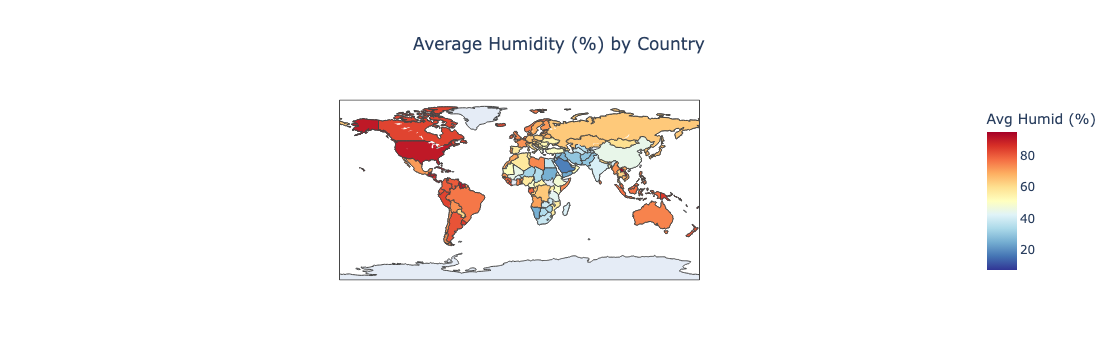

In [12]:
import plotly.express as px
import pandas as pd

# Exploratory Data Analysis (EDA) - World Map - Average Humidity in Percent
df = pd.read_csv("GlobalWeatherRepository.csv")

avg_temp = df.groupby('country', as_index=False)['humidity'].mean()
# World Map
fig = px.choropleth(
    avg_temp,
    locations='country',
    locationmode='country names',
    color='humidity',
    color_continuous_scale='RdYlBu_r',
    title='Average Humidity (%) by Country',
    labels={'humidity': 'Avg Humid (%)'}
)
fig.update_layout(
    title_x=0.5,
    height=600 
)
fig.show()

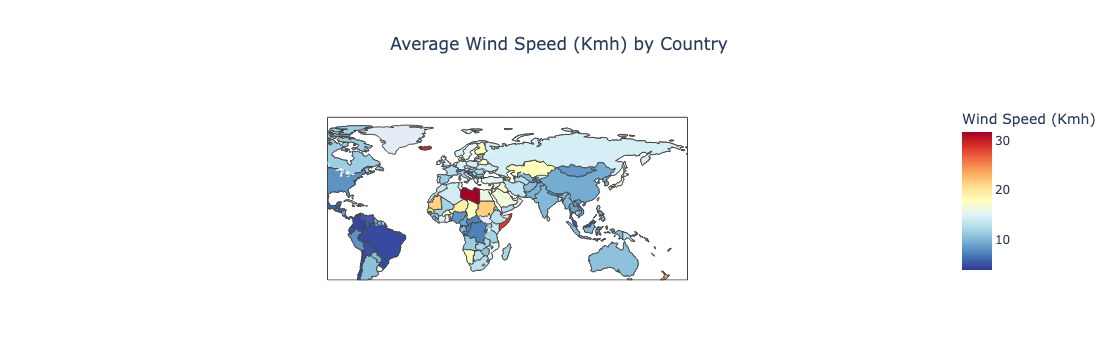

In [7]:
import plotly.express as px
import pandas as pd

# Exploratory Data Analysis (EDA) - World Map - Average Wind Speed in Kmh
df = pd.read_csv("GlobalWeatherRepository.csv")

avg_temp = df.groupby('country', as_index=False)['wind_kph'].mean()
# World Map
fig = px.choropleth(
    avg_temp,
    locations='country',
    locationmode='country names',
    color='wind_kph',
    color_continuous_scale='RdYlBu_r',
    title='Average Wind Speed (Kmh) by Country',
    labels={'wind_kph': 'Wind Speed (Kmh)'}
)
fig.update_layout(
    title_x=0.5,
    height=600 
)
fig.show()

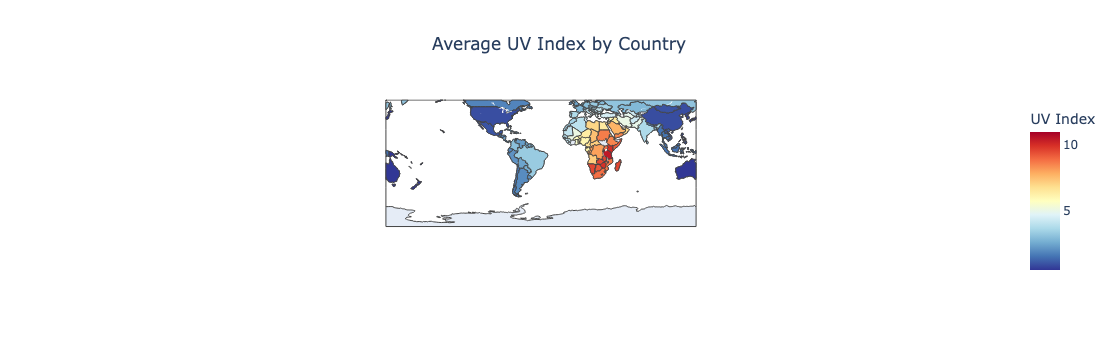

In [9]:
import plotly.express as px
import pandas as pd

# Exploratory Data Analysis (EDA) - World Map - Average UV Index
df = pd.read_csv("GlobalWeatherRepository.csv")

avg_temp = df.groupby('country', as_index=False)['uv_index'].mean()
# World Map
fig = px.choropleth(
    avg_temp,
    locations='country',
    locationmode='country names',
    color='uv_index',
    color_continuous_scale='RdYlBu_r',
    title='Average UV Index by Country',
    labels={'uv_index': 'UV Index'}
)
fig.update_layout(
    title_x=0.5,
    height=600 
)
fig.show()

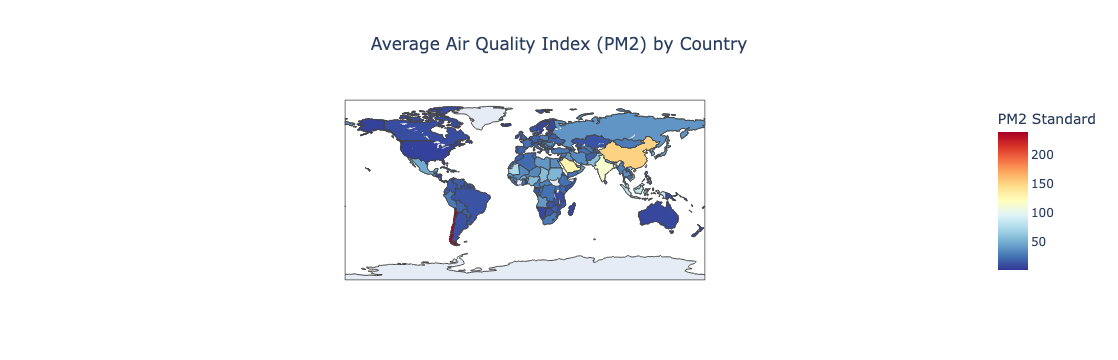

In [15]:
import plotly.express as px
import pandas as pd

# Exploratory Data Analysis (EDA) - World Map - Average Air Quality in PM2 Standard
df = pd.read_csv("GlobalWeatherRepository.csv")

avg_temp = df.groupby('country', as_index=False)['air_quality_PM2.5'].mean()
# World Map
fig = px.choropleth(
    avg_temp,
    locations='country',
    locationmode='country names',
    color='air_quality_PM2.5',
    color_continuous_scale='RdYlBu_r',
    title='Average Air Quality Index (PM2) by Country',
    labels={'air_quality_PM2.5': 'PM2 Standard'}
)
fig.update_layout(
    title_x=0.5,
    height=600 
)
fig.show()

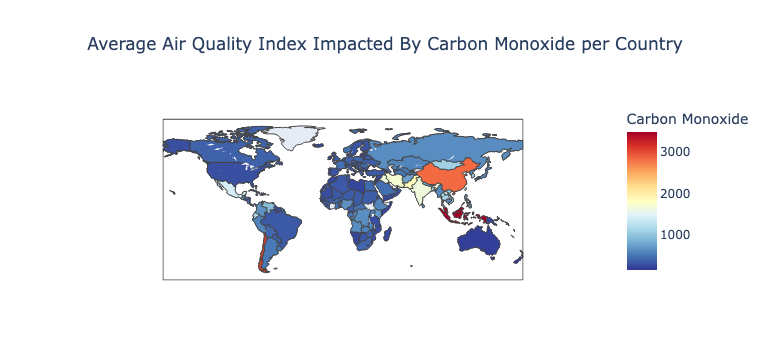

In [3]:
import plotly.express as px
import pandas as pd

# Exploratory Data Analysis (EDA) - World Map - Average Air Quality Index Impacted By Carbon Monoxide per Country
df = pd.read_csv("GlobalWeatherRepository.csv")

avg_temp = df.groupby('country', as_index=False)['air_quality_Carbon_Monoxide'].mean()
# World Map
fig = px.choropleth(
    avg_temp,
    locations='country',
    locationmode='country names',
    color='air_quality_Carbon_Monoxide',
    color_continuous_scale='RdYlBu_r',
    title='Average Air Quality Index Impacted By Carbon Monoxide per Country',
    labels={'air_quality_Carbon_Monoxide': 'Carbon Monoxide'}
)
fig.update_layout(
    title_x=0.5,
    height=600 
)
fig.show()

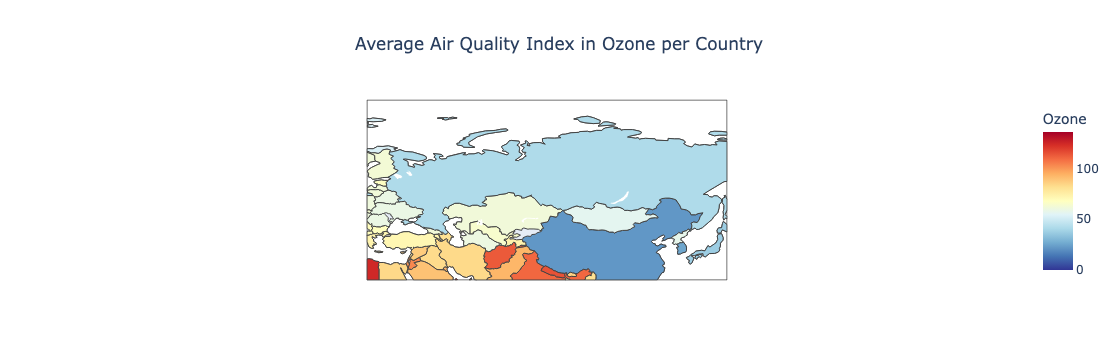

In [5]:
import plotly.express as px
import pandas as pd

# Exploratory Data Analysis (EDA) - World Map - Average Air Quality Index in Ozone per Country
df = pd.read_csv("GlobalWeatherRepository.csv")

avg_temp = df.groupby('country', as_index=False)['air_quality_Ozone'].mean()
# World Map
fig = px.choropleth(
    avg_temp,
    locations='country',
    locationmode='country names',
    color='air_quality_Ozone',
    color_continuous_scale='RdYlBu_r',
    title='Average Air Quality Index in Ozone per Country',
    labels={'air_quality_Ozone': 'Ozone'}
)
fig.update_layout(
    title_x=0.5,
    height=600 
)
fig.show()

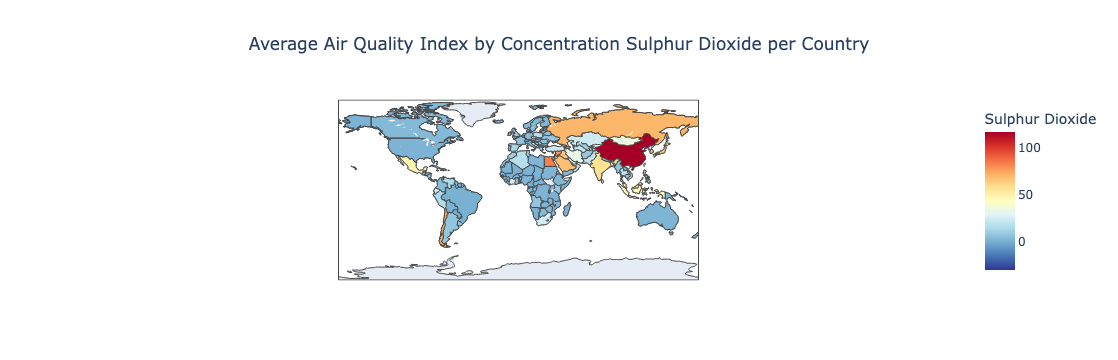

In [3]:
import plotly.express as px
import pandas as pd

# Exploratory Data Analysis (EDA) - World Map - Average Air Quality Index by Concentration Sulphur Dioxide per Country
df = pd.read_csv("GlobalWeatherRepository.csv")

avg_temp = df.groupby('country', as_index=False)['air_quality_Sulphur_dioxide'].mean()
# World Map
fig = px.choropleth(
    avg_temp,
    locations='country',
    locationmode='country names',
    color='air_quality_Sulphur_dioxide',
    color_continuous_scale='RdYlBu_r',
    title='Average Air Quality Index by Concentration Sulphur Dioxide per Country',
    labels={'air_quality_Sulphur_dioxide': 'Sulphur Dioxide'}
)
fig.update_layout(
    title_x=0.5,
    height=600 
)
fig.show()

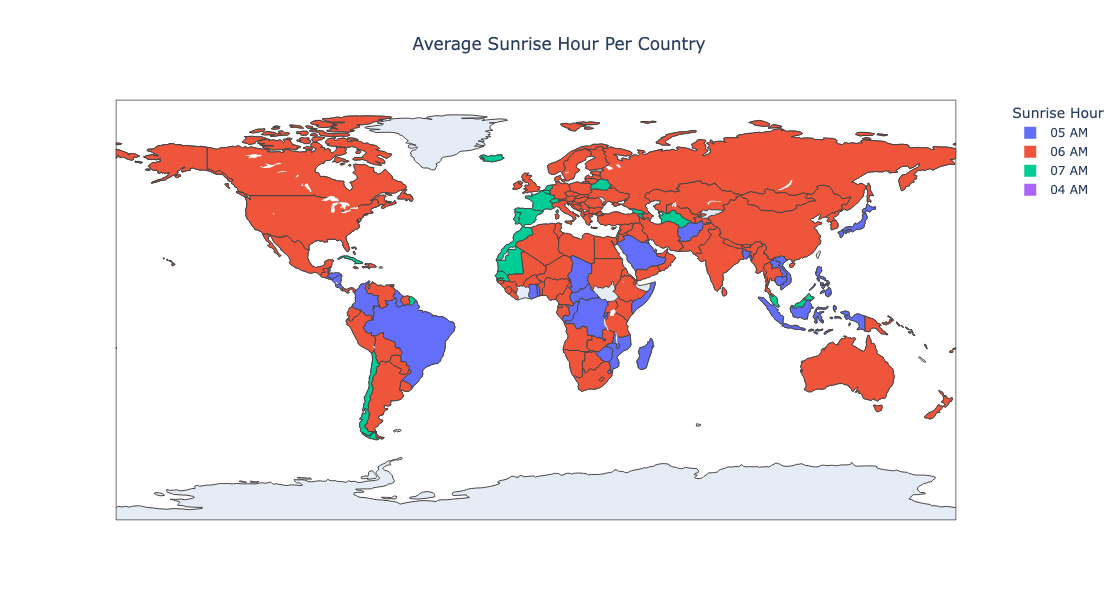

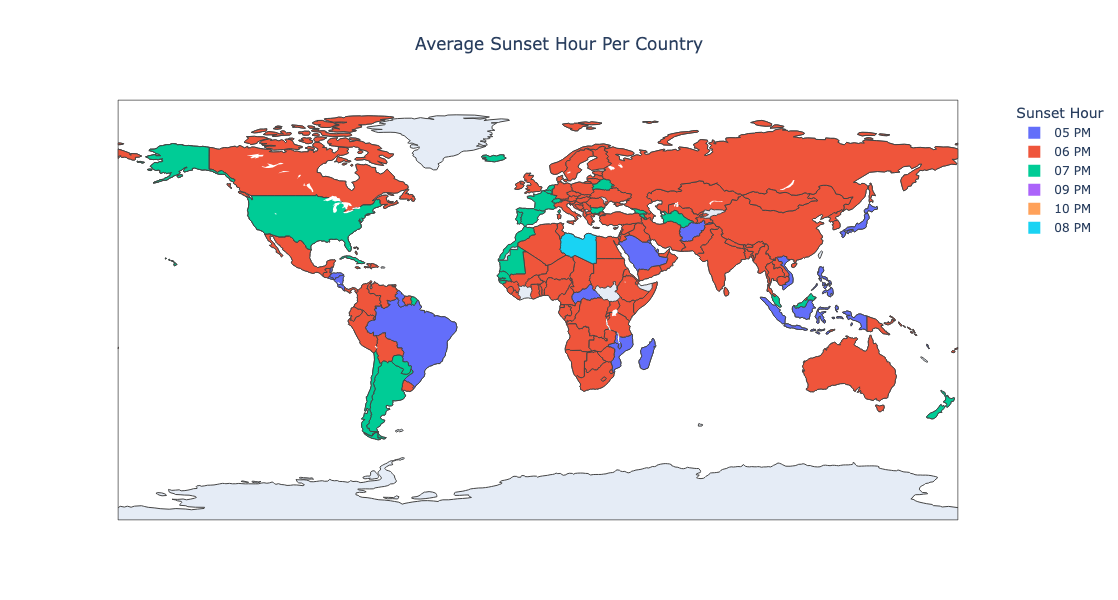

In [17]:
import plotly.express as px
import pandas as pd
from datetime import datetime, timedelta

# Exploratory Data Analysis (EDA) - World Map - Country Average Sunrise & Sunset Time
# Load dataset
df = pd.read_csv("GlobalWeatherRepository.csv")

target_col = ['sunrise','sunset']

for dt in target_col:    
    # Convert 'sunrise' to datetime
    df[f"{dt}_dt"] = pd.to_datetime(df[dt], format='%I:%M %p')
    
    # Convert time to seconds since midnight
    df[f"{dt}_seconds"] = df[f"{dt}_dt"].dt.hour * 3600 + df[f"{dt}_dt"].dt.minute * 60
    
    # Group by country and get average sunrise in seconds
    avg_ctx = df.groupby('country', as_index=False)[f"{dt}_seconds"].mean()
    
    # Convert seconds to "HH AM/PM" string
    def format_hour_group(seconds):
        dt = datetime(1900, 1, 1) + timedelta(seconds=seconds)
        return dt.strftime("%I %p") 
    
    avg_ctx[f"{dt}_hour_group"] = avg_ctx[f"{dt}_seconds"].apply(format_hour_group)
    
    # Choropleth Map by Sunrise Hour Group
    fig = px.choropleth(
        avg_ctx,
        locations='country',
        locationmode='country names',
        color=f"{dt}_hour_group",
        title=f"Average {dt.title()} Hour Per Country",
        labels={f"{dt}_hour_group": f"{dt.title()} Hour"},
        hover_name='country',
        hover_data={f"{dt}_hour_group": True}
    )
    
    fig.update_layout(
        title_x=0.5,
        height=600
    )
    
    fig.show()